## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
import torch.nn as nn

## Utils

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
n_cudas = torch.cuda.device_count()
for i in range(n_cudas):
    print(torch.cuda.get_device_name(i))

NVIDIA A100-SXM4-80GB


## Data Preparation

In [4]:
data = pd.read_csv('housing.csv')

data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
low_price_houses = data[data['median_house_value'] < 500000].reset_index()
X = low_price_houses["median_income"]
y = low_price_houses['median_house_value']

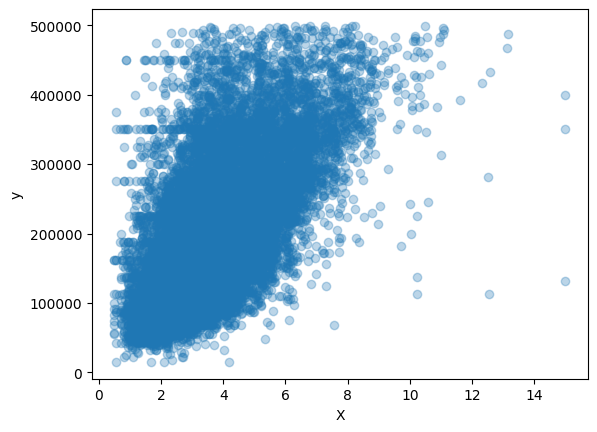

In [6]:
plt.scatter(X, y, alpha=0.3)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

### Split first!

In [7]:
N = len(X)
idx = np.arange(N)
np.random.shuffle(idx)

train_idx = idx[:int(N*0.8)]
val_idx = idx[int(N*0.8):]

len(train_idx), len(val_idx)

(15718, 3930)

In [8]:
X_train, y_train = X[train_idx].to_numpy(), y[train_idx].to_numpy()
X_val, y_val = X[val_idx].to_numpy(), y[val_idx].to_numpy()

In [9]:
X_train_tensor = torch.as_tensor(X_train).float().to(device)
y_train_tensor = torch.as_tensor(y_train).float().to(device)

In [10]:
print(type(X_train), type(X_train_tensor), X_train_tensor.type())

<class 'numpy.ndarray'> <class 'torch.Tensor'> torch.cuda.FloatTensor


## Model

In [11]:
torch.manual_seed(0)

w = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
b = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)

print(w, b)

tensor([-0.9247], device='cuda:0', requires_grad=True) tensor([0.1808], device='cuda:0', requires_grad=True)


In [12]:
y_hat = w * X_train_tensor + b

error = (y_hat - y_train_tensor)
loss = (error ** 2).mean()
loss

tensor(4.6414e+10, device='cuda:0', grad_fn=<MeanBackward0>)

In [13]:
y_hat_pdf = pd.DataFrame(y_hat.cpu().detach().numpy())

In [14]:
y_hat_pdf

,0
0,-1.321751
1,-5.440289
2,-4.459778
3,-3.577003
4,-1.047773
...,...
15713,-2.708744
15714,-2.118440
15715,-1.581211
15716,-4.018713


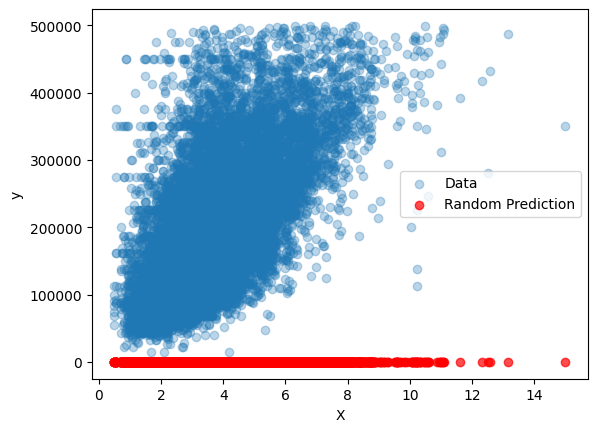

In [15]:
plt.scatter(X_train, y_train, alpha=0.3, label="Data")
plt.scatter(X_train, y_hat_pdf, alpha=0.7, color="red", label="Random Prediction")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Training

In [16]:
lr = 0.01

torch.manual_seed(0)

b = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
w = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)

optimizer = optim.SGD([b, w], lr=lr)

epochs = 1000
for epoch in range(epochs):
    y_hat = X_train_tensor * w + b
    error = (y_hat - y_train_tensor)
    loss = (error ** 2).mean()
    
    loss.backward()
    
    optimizer.step()
    optimizer.zero_grad()
    
print(w, b)

tensor([40655.9609], device='cuda:0', requires_grad=True) tensor([42441.8945], device='cuda:0', requires_grad=True)


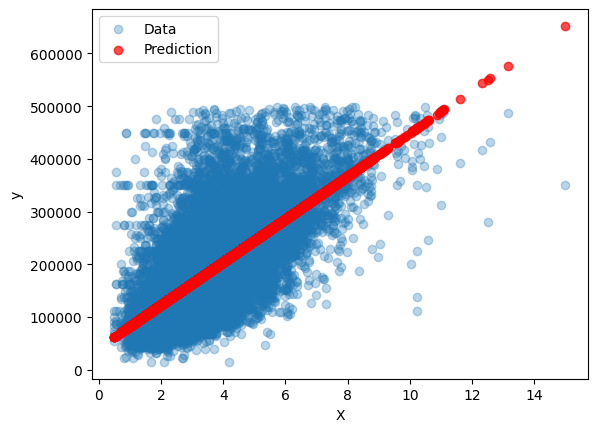

In [17]:
y_hat = w * X_train_tensor + b
y_hat_pdf = pd.DataFrame(y_hat.cpu().detach().numpy())

plt.scatter(X_train, y_train, alpha=0.3, label="Data")
plt.scatter(X_train, y_hat_pdf, alpha=0.7, color="red", label="Prediction")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()